In [ ]:
#Algorithm outline and testing
""" goal is to remove the 'static object' detection and just have the moving object detection then see how viable this approach is 
compared to static AND moving object detection like in algorithm 1 implementation. The goal is to be able to track moving flies at near real-time" 

In [1]:
# === PART 1: DETECT & LOCALIZE FLIES PER FRAME ===
""" goal is to record latency of frame substraction, ensure that program can keep track of multiple flies in each frame """

#imports
import cv2
import time
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import linear_sum_assignment
from collections import deque

In [3]:
#constants
VIDEO_PATH = "LUCID_TRI032S-M_251700592__20251114112116359_video3.avi" #path to AVI file
DOWNSCALE = 1.0 #<1.0 to downscale frames for speed
THRESH_VAL = 25 # frame subtraction threshold
MIN_AREA = 5 # minimum blob area (pixels)
MAX_AREA = 500 # max blob area (pixels)
MAX_MISSED = 10 # allows tracks to survive 10 frames without a detection
MAX_TRACK_DIST = 50 # max distance for track association (pixels)
HISTORY = 50 # frame to keep for plotting

# ROI Configuration
# define ROI as fractions of frame dimensions
ROI_X_MIN = 0.5
ROI_Y_MIN = 0.0

# Precomputed morphology kernels (create once)
kernel3 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3,3))
kernel5 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5,5))

# Precompute a small circle mask for radius 6
CIRCLE_RADIUS = 20
circle_mask = np.zeros((2*CIRCLE_RADIUS+1, 2*CIRCLE_RADIUS+1), dtype=np.uint8)
cv2.circle(circle_mask, (CIRCLE_RADIUS, CIRCLE_RADIUS), CIRCLE_RADIUS, 255, -1)



array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8)

In [5]:
#tracking class
class Track: 
    def __init__(self, track_id, centroid): 
        self.id = track_id
        self.centroids = deque(maxlen=HISTORY)
        self.centroids.append(centroid)
        #self.last_seen = 0 # frame idx when last seen
        self.missed = 0 # num of consecutive frames w/o detection

        # ADD KALMAN STATE
        # using initial vector [x, y, vx, vy]T
        self.kf = cv2.KalmanFilter(4,2)
        self.kf.transitionMatrix = np.array([
            [1, 0, dt, 0],
            [0, 1, 0, dt], 
            [0, 0, 1, 0], 
            [0, 0, 0, 1]], np.float32)

        self.kf.measurementMatrix=np.array([
            [1, 0, 0, 0],
            [0, 1, 0, 0]], np.float32)

        self.kf.processNoiseCov = np.eye(4, dtype=np.float32) *1e-2
        self.kf.measurementNoiseCov = np.eye(2, dtype=np.float32) * 1e-1

        self.kf.statePre = np.array([[centroid[0]],
                                     [centroid[1]],
                                     [0],
                                     [0]], np.float32)

    def predict(self): 
        pred = self.kf.predict()
        return pred[0,0], pred[1,0]

    def update(self, detection=None):
        if detection is not None: 
            measured = np.array([[np.float32(detection[0])],
                                 [np.float32(detection[1])]])
            self.kf.correct(measured)
            self.centroids.append(self.centroids[-1])
            self.missed += 1

    @property
    def last_position(self): 
        return self.centroids[-1] # returns last position stored in centroid

In [7]:
# utility functions
def preprocess_and_crop(frame):
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    #gray =cv2.equalizeHist(gray)

    h, w = gray.shape 

    # Define ROI fractions (example: right half)
    x0 = int(ROI_X_MIN * w)
    y0 = int(ROI_Y_MIN * h)
    x1 = w
    y1 = h

    roi = gray[y0:y1, x0:x1]

    # force consistent minimum size
    if roi.shape[0] < 8 or roi.shape[1] < 8:
        raise ValueError(f"ROI too small: {roi.shape} from frame {gray.shape}")

    return roi, (x0, y0)


def detect_moving_objects_fast(prev_gray, curr_gray):
    diff = cv2.absdiff(curr_gray, prev_gray)
    diff = cv2.GaussianBlur(diff, (5,5), 0)
    _, thresh = cv2.threshold(diff, THRESH_VAL, 255, cv2.THRESH_BINARY)
    # reuse kernel3, do NOT create a new one
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel3)

    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(thresh)
    detections = []
    for i in range(1, num_labels):
        area = stats[i, cv2.CC_STAT_AREA]
        if MIN_AREA <= area <= MAX_AREA:
            cx, cy = centroids[i]
            detections.append((int(cx), int(cy)))
    return detections, thresh


def associate_detections_to_tracking_fast(detections, tracks, next_id):
    if not detections: 
        for t in tracks: 
            t.missed +=1 
            # repeat last position for smooth trajectory; TODO see if needed
            t.centroids.append(t.last_position)
        return [t for t in tracks if t.missed <= MAX_MISSED], next_id

    used = np.zeros(len(detections), dtype=bool)

    # match existing tracks using greedy algorithm 
    for t in tracks: 
        #dists = np.linalg.norm(np.array(detections) - np.array(t.last_position), axis = 1)
        dists = np.linalg.norm(np.array(detections) - np.array(t.predict()), axis = 1)
        idx = np.argmin(dists)

        if dists[idx] < MAX_TRACK_DIST and not used[idx]: 
            t.centroids.append(detections[idx])
            t.missed = 0
            used[idx] = True
        else: 
            t.missed += 1
            t.centroids.append(t.last_position)

    # generate new tracks ONLY for unmatched detections
    for i, d in enumerate (detections): 
        if not used[i]: 
            tracks.append(Track(next_id, d))
            next_id += 1

    # remove old tracks
    tracks = [t for t in tracks if t.missed <=MAX_MISSED]

    return tracks, next_id


def deduplicate_tracks(tracks, radius=5): 
    # prevent same location collapse
    if len(tracks) <=1: 
        return tracks

    keep = []
    for t in tracks: 
        if not any(np.linalg.norm(
            np.array(t.last_position) - np.array(k.last_position)
        ) < radius for k in keep): 
            keep.append(t)
    return keep


    

In [25]:
# MAIN PROCESSING LOOP

def process_video(): 
    print(f"beginning...\n") 
    capture = cv2.VideoCapture(VIDEO_PATH)
    assert capture.isOpened(), "Could not open video file"
    
    ret, frame = capture.read()
    if not ret: 
        raise RuntimeError("Failed to read first frame")
        
    prev_gray, roi_offset = preprocess_and_crop(frame)
    
    #initialize background model for static detection
    bg_model_fast = prev_gray.copy() 
    bg_model_slow = prev_gray.copy() #np.ones_like(prev_gray, dtype=np.uint8) * 255
    persist_map=np.zeros_like(prev_gray, dtype=np.uint8)
    
    # instantiate empty arrays for tracking and latency calculations
    tracks = [] #store tracking in array
    next_track_id = 0 
    #explicit multi-target capacity metrics
    latencies, det_counts, track_counts, frames, thresh_frames = [], [], [], [], []
       
        #frames = []
        #thresh_frames = []
    
    # precompute grids ONCE
    H, W = prev_gray.shape
    yy, xx = np.mgrid[0:H, 0:W]
    CIRCLE_RADIUS_SQ = CIRCLE_RADIUS ** 2
    
    frame_idx = 0
    
    #begin loop, occurs over duration of video
    while True: 
        ret, frame = capture.read()
        if not ret: 
            break
    
        start_frame = time.perf_counter() #records detection speed
    
         # Preprocess & crop
        start = time.perf_counter()
        curr_gray, _ = preprocess_and_crop(frame)
        t_preprocess = time.perf_counter() - start
    
        # Moving detection
        start = time.perf_counter()
        detections, thresh = detect_moving_objects_fast(prev_gray, curr_gray)
        t_move = time.perf_counter() - start
    
    
    
        # tracking only (no merging) 
        start = time.perf_counter()
        tracks, next_track_id = associate_detections_to_tracking_fast(
            detections, tracks, next_track_id
        )
        tracks = deduplicate_tracks(tracks) # one track per fly, protect stationary leak
        t_tracking = time.perf_counter() - start

        
        # Visualization
        start = time.perf_counter()
        visual = cv2.cvtColor(curr_gray, cv2.COLOR_GRAY2BGR)
        cv2.rectangle(visual, (0,0), (visual.shape[1]-1, visual.shape[0]-1), (255,255,0), 1)
        for t in tracks:
            for i in range(1, len(t.centroids)):
                # repeat n times
                cv2.line(visual, t.centroids[i-1], t.centroids[i], (0,255,0), 1)
            # do NOT repeat n times (moved outside loop)
            cv2.circle(visual, t.last_position, 3, (0,0,255), -1)
            cv2.putText(visual, f"ID {t.id}", (t.last_position[0]+5, t.last_position[1]-5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255,0,0), 1)
            if frame_idx % 10 == 0:
                frames.append(visual.copy())
                thresh_frames.append(thresh.copy())
        t_vis = time.perf_counter() - start
    
        # Metrics
        total_frame = (time.perf_counter() - start_frame) * 1000.0
        print(f"Frame {frame_idx}: preprocess={t_preprocess*1000:.1f}ms, "
              f"move={t_move*1000:.1f}ms, "
              f"tracking={t_tracking*1000:.1f}ms,"
              f"vis={t_vis*1000:.1f}ms, total={total_frame:.1f}ms")

        latencies.append(total_frame)
        det_counts.append(len(detections))
        track_counts.append(len(tracks))

    
        prev_gray = curr_gray
        frame_idx += 1
    

    capture.release()
    print ("Done processing.")
    return latencies, det_counts, track_counts, frames, thresh_frames
        

In [27]:
import cProfile
import pstats


latencies, det_counts, track_counts, frames, thresh_frames = process_video()

beginning...

Frame 0: preprocess=2.5ms, move=17.1ms, tracking=0.0ms,vis=1.8ms, total=21.4ms
Frame 1: preprocess=3.1ms, move=17.4ms, tracking=0.2ms,vis=8.4ms, total=29.0ms
Frame 2: preprocess=2.2ms, move=21.1ms, tracking=2.4ms,vis=3.8ms, total=29.6ms
Frame 3: preprocess=4.3ms, move=14.2ms, tracking=0.5ms,vis=3.5ms, total=22.6ms
Frame 4: preprocess=2.1ms, move=16.6ms, tracking=0.7ms,vis=3.0ms, total=22.3ms
Frame 5: preprocess=2.4ms, move=14.3ms, tracking=0.6ms,vis=3.3ms, total=20.6ms
Frame 6: preprocess=3.7ms, move=19.8ms, tracking=0.6ms,vis=3.0ms, total=27.1ms
Frame 7: preprocess=2.2ms, move=17.5ms, tracking=0.7ms,vis=3.0ms, total=23.3ms
Frame 8: preprocess=2.7ms, move=16.3ms, tracking=0.7ms,vis=2.9ms, total=22.5ms
Frame 9: preprocess=1.8ms, move=15.1ms, tracking=0.9ms,vis=3.4ms, total=21.3ms
Frame 10: preprocess=2.0ms, move=18.4ms, tracking=0.3ms,vis=12.7ms, total=33.5ms
Frame 11: preprocess=2.1ms, move=14.4ms, tracking=0.3ms,vis=3.2ms, total=20.0ms
Frame 12: preprocess=1.7ms, move=15

Average per-frame latency: 29.79 ms
Max per-frame latency: 1541.63 ms
Estimated FPS capability: 33.6 FPS


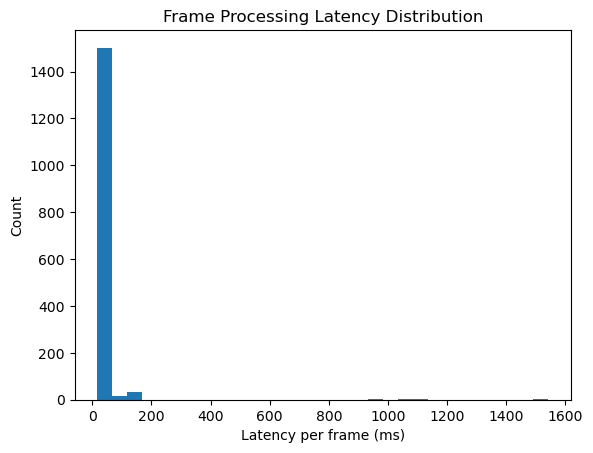

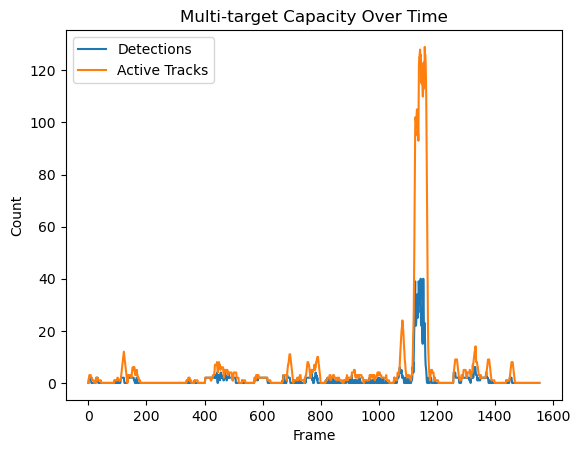

In [29]:
# === RESULTS AND DIAGNOSTICS ===

# latency metrics
#print(f"Processed {frame_idx} frames")
print(f"Average per-frame latency: {np.mean(latencies):.2f} ms")
print(f"Max per-frame latency: {np.max(latencies):.2f} ms")
print(f"Estimated FPS capability: {1000.0 / np.mean(latencies):.1f} FPS")

# plot latency distribution 
plt.figure()
plt.hist(latencies, bins=30)
plt.xlabel("Latency per frame (ms)")
plt.ylabel("Count")
plt.title("Frame Processing Latency Distribution")
plt.show()

#plot detection metrics to quantitatively show scaling behavior
plt.figure()
plt.plot(det_counts, label="Detections")
plt.plot(track_counts, label="Active Tracks")
plt.legend()
plt.title("Multi-target Capacity Over Time")
plt.xlabel("Frame")
plt.ylabel("Count")
plt.show()

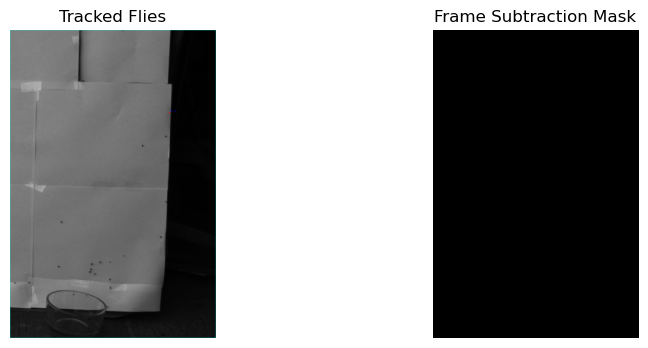

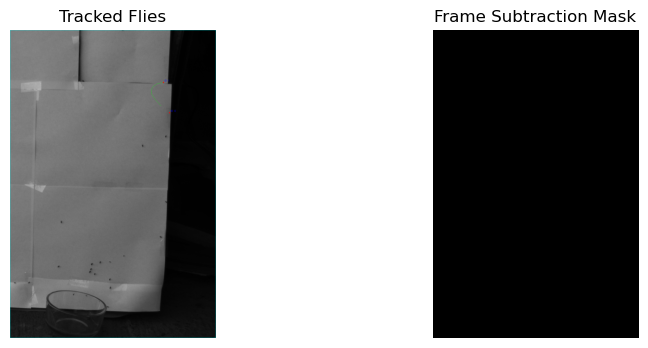

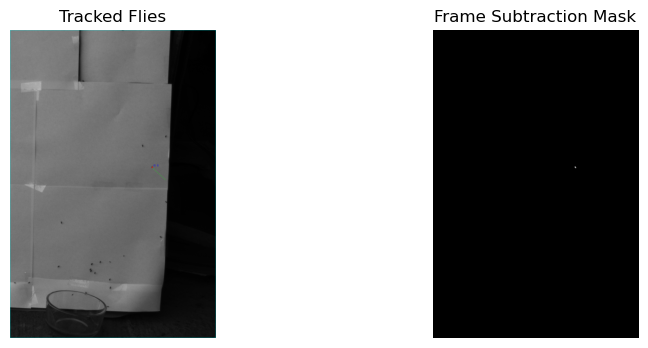

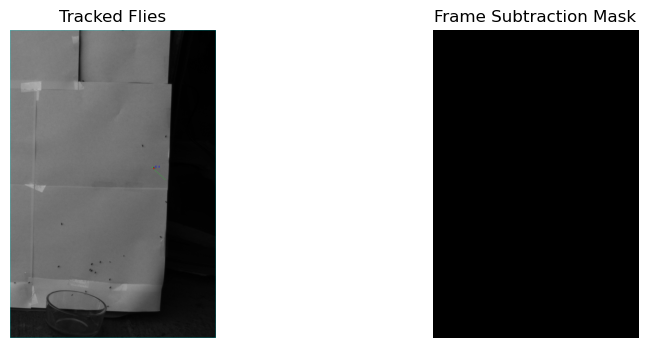

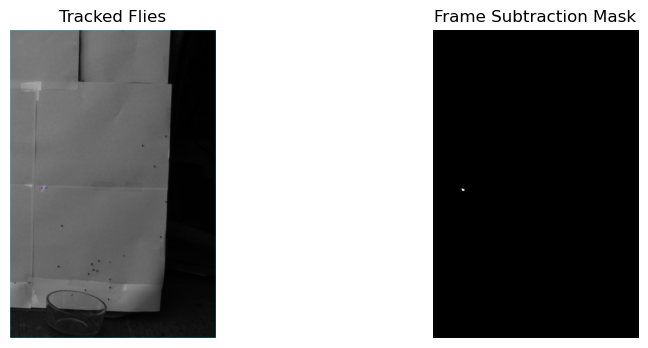

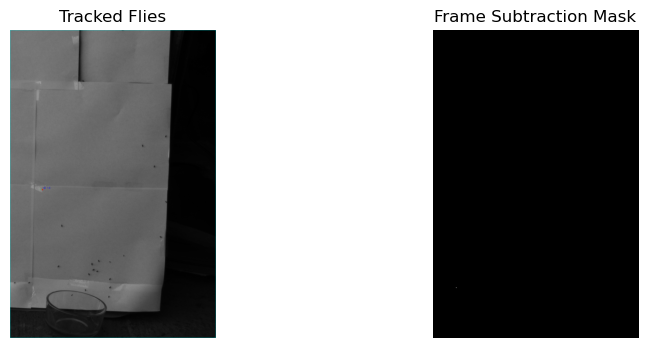

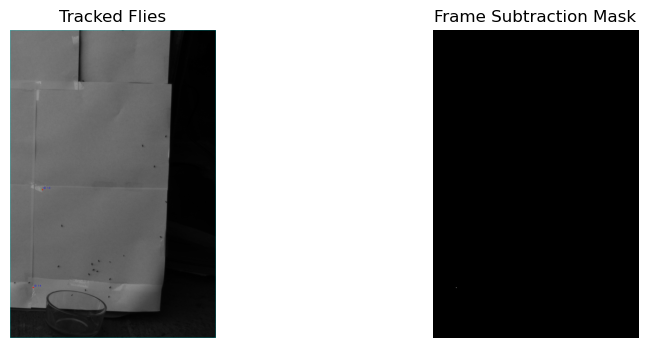

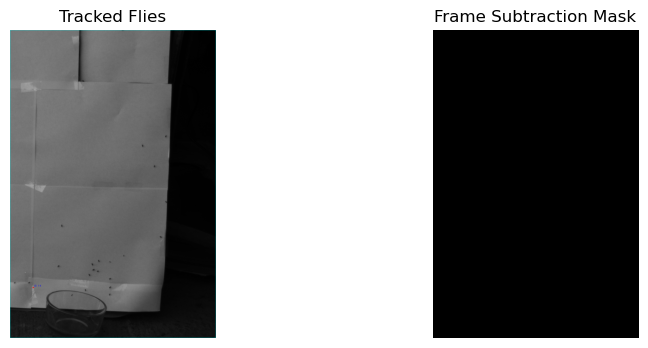

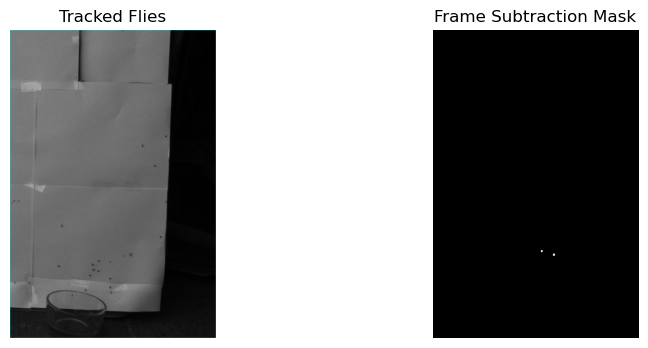

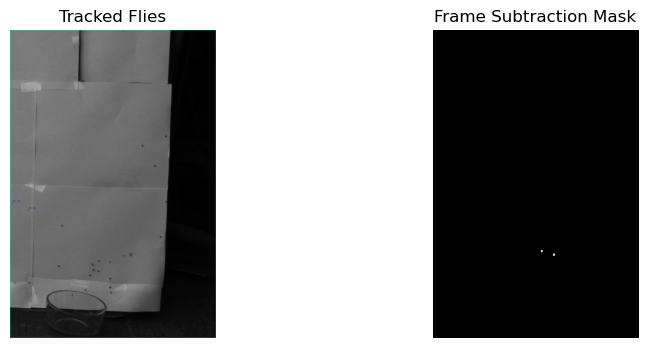

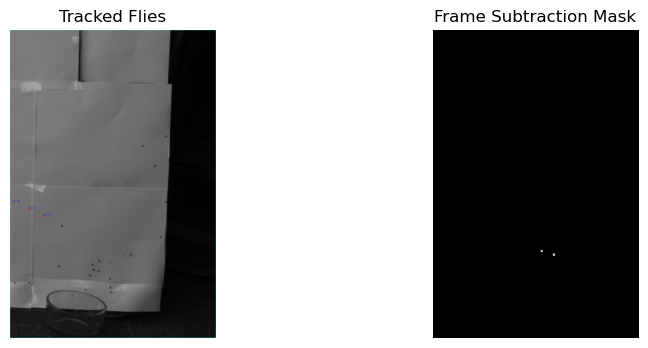

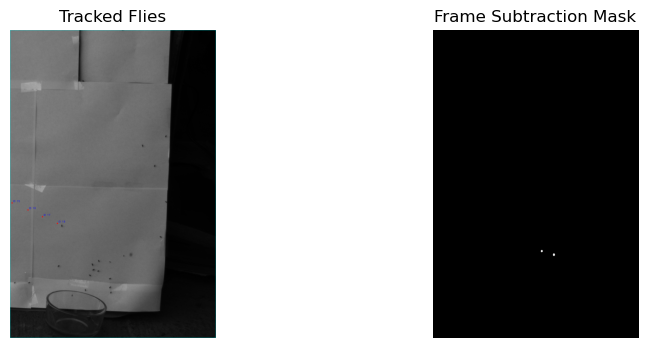

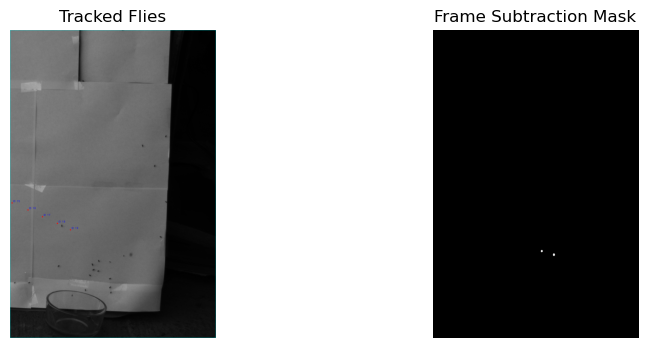

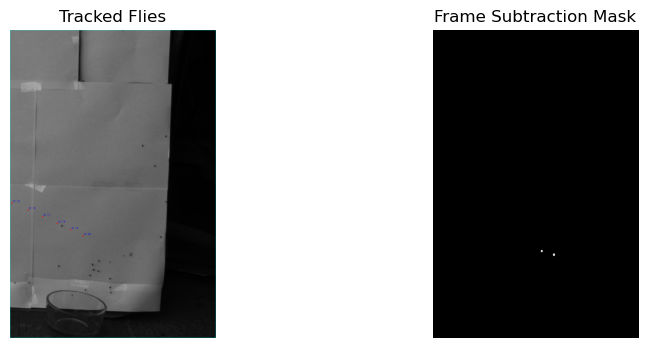

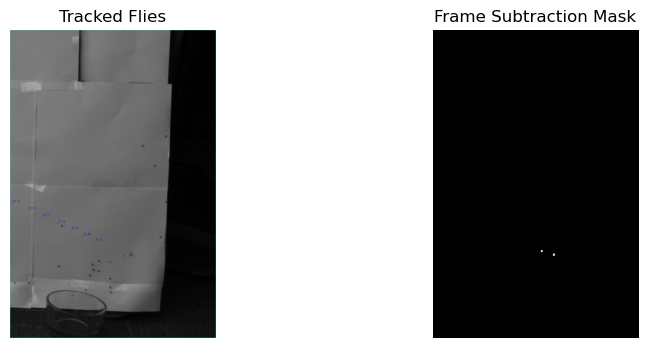

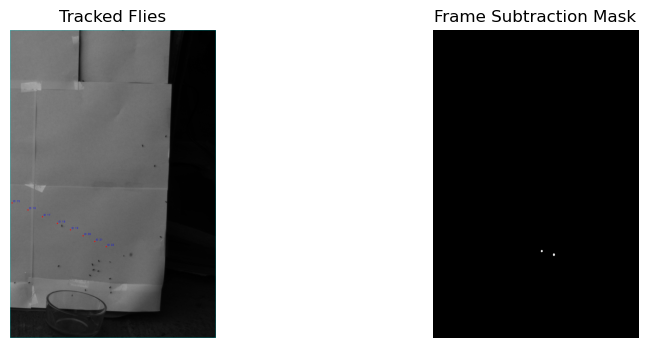

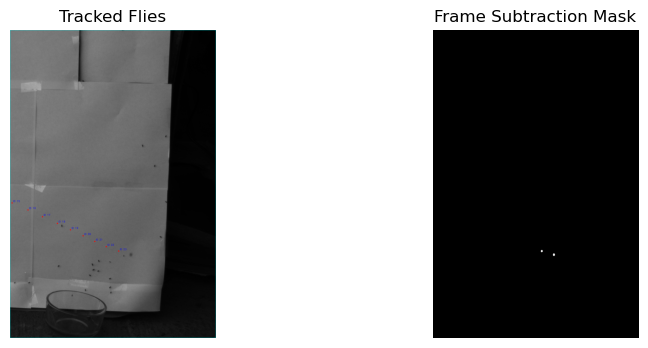

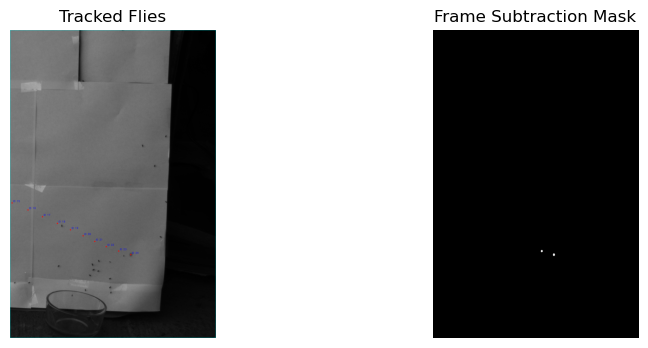

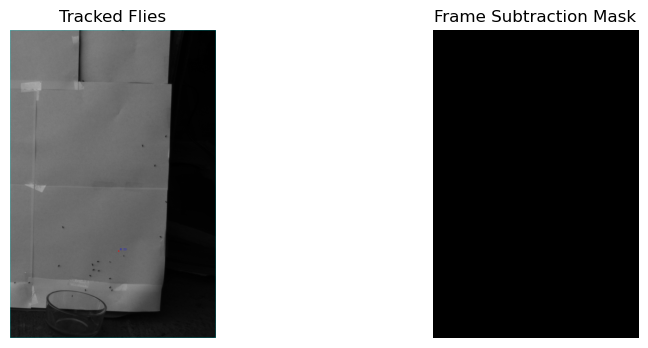

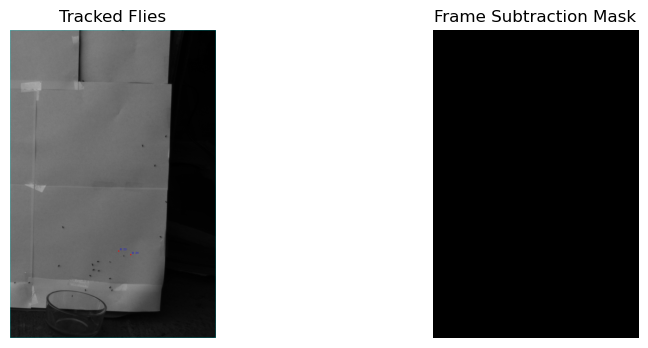

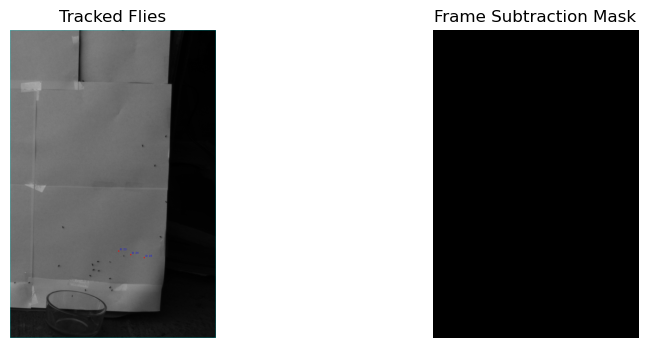

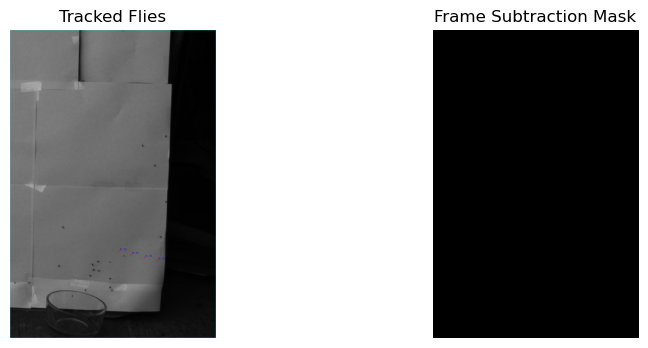

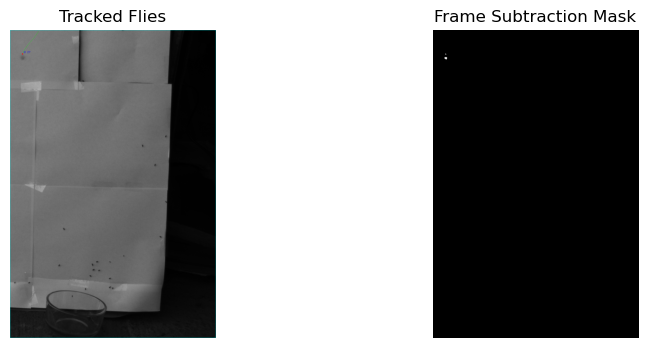

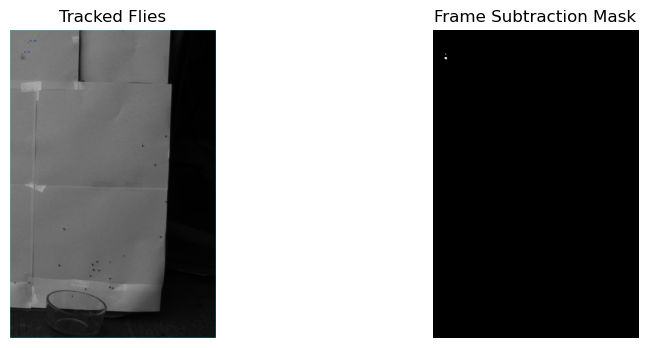

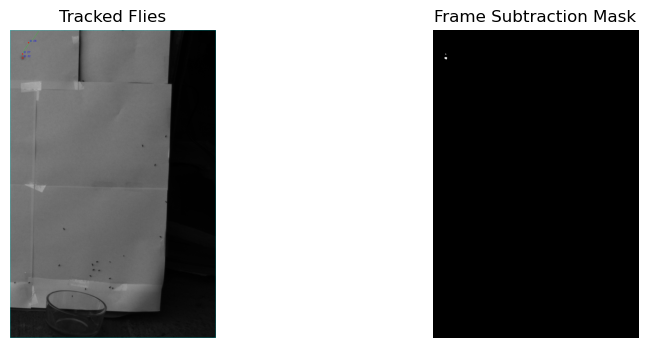

In [31]:
# example frames
num_show = min(25, len(frames))
for i in range(num_show):
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.imshow(frames[i][..., ::-1])
    plt.title("Tracked Flies")
    plt.axis("off")
    
    
    plt.subplot(1,2,2)
    plt.imshow(thresh_frames[i], cmap='gray')
    plt.title("Frame Subtraction Mask")
    plt.axis("off")
    plt.show()

# TODO FIGURE OUT HOW TO VALIDATE FRAME SUBTRACTION/ACCURACY - MAYBE CUT/SAMPLE PARTICULAR VIDEO SECTIONS 

In [ ]:
# ADD ABLATION TO COMPARE EFFICACY VS CURRENT ALGORITHM 
""" KEY HYPOTHESIS: 
1. DISCOVERY RECALL REMAINS UNCHANGED
2. TRACK CONTINUITY IMPROVES OR STAYS EQUAL
3. LATENCY DROPS SIGNIFICANTLY
4. FALSE POSITIVES TO NO INCREASE MATERIALLY """